# Cell 1: Import Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os

# Cell 2: Load Datasets

In [5]:
# Define file paths
training_data_path = "../data/training_data.csv"
testing_data_path = "../data/testing_data.csv"

# Load training and testing datasets
train_data = pd.read_csv(training_data_path)
test_data = pd.read_csv(testing_data_path)

# Display basic info
print("Training Data Shape:", train_data.shape)
print("Testing Data Shape:", test_data.shape)
print("\nTraining Data Info:")
print(train_data.info())
print("\nTesting Data Info:")
print(test_data.info())

Training Data Shape: (4920, 134)
Testing Data Shape: (42, 133)

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB
None

Testing Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 43.8+ KB
None


# Cell 3: Exploratory Data Analysis (EDA)

Data types of columns:
itching                   int64
skin_rash                 int64
nodal_skin_eruptions      int64
continuous_sneezing       int64
shivering                 int64
                         ...   
blister                   int64
red_sore_around_nose      int64
yellow_crust_ooze         int64
prognosis                object
Unnamed: 133            float64
Length: 134, dtype: object


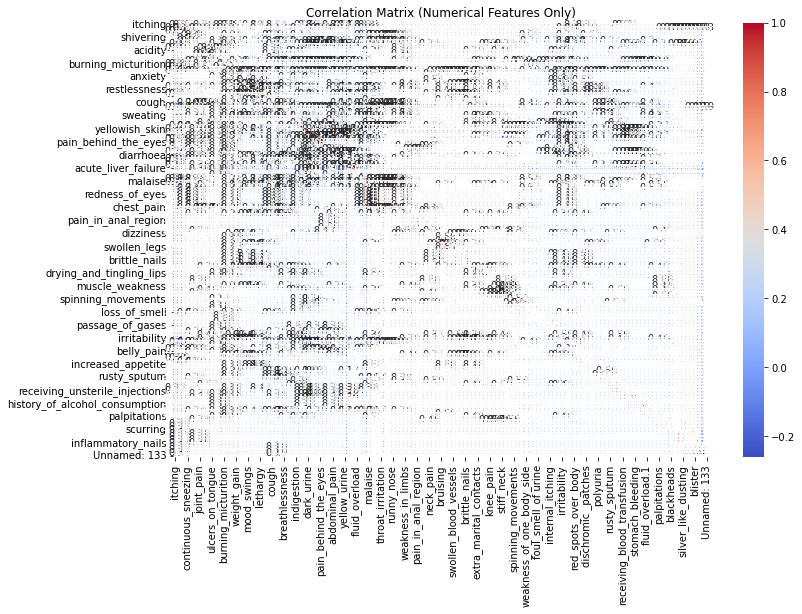

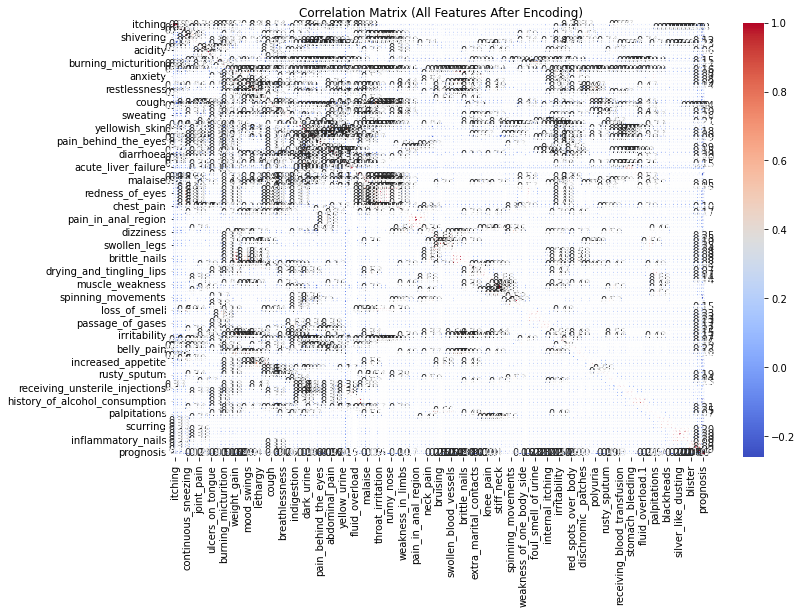

In [11]:
# Check data types
print("Data types of columns:")
print(train_data.dtypes)

# --- Option 1: Correlation for numerical columns only ---
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
numerical_train_data = train_data[numerical_cols]

plt.figure(figsize=(12, 8))
sns.heatmap(numerical_train_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numerical Features Only)")
plt.show()

# --- Option 2: Encode categorical columns and calculate correlation ---
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
categorical_cols = train_data.select_dtypes(include=['object']).columns

# Encode categorical columns
for col in categorical_cols:
    train_data[col] = label_encoder.fit_transform(train_data[col])

# Calculate correlation for all columns
plt.figure(figsize=(12, 8))
sns.heatmap(train_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (All Features After Encoding)")
plt.show()

 # Cell 4: Data Preprocessing

In [15]:
import numpy as np

# --- Debugging: Check columns in both datasets ---
print("Columns in training data:", train_data.columns.tolist())
print("\nColumns in testing data:", test_data.columns.tolist())

# --- Align columns ---
# Drop 'Unnamed: 133' from training data (since it's not in testing data)
if "Unnamed: 133" in train_data.columns:
    train_data = train_data.drop(columns=["Unnamed: 133"])

# Ensure column order matches
test_data = test_data[train_data.columns]

# --- Handle missing values for numerical columns ---
numerical_cols = train_data.select_dtypes(include=["int64", "float64"]).columns

# Use .loc to avoid SettingWithCopyWarning
train_data.loc[:, numerical_cols] = train_data[numerical_cols].fillna(train_data[numerical_cols].mean())
test_data.loc[:, numerical_cols] = test_data[numerical_cols].fillna(test_data[numerical_cols].mean())

# --- Handle missing values for categorical columns ---
categorical_cols = train_data.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    # Use .loc for categorical columns as well
    train_data.loc[:, col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data.loc[:, col] = test_data[col].fillna(test_data[col].mode()[0])

print("\nPreprocessing complete. Columns aligned and missing values handled.")

Columns in training data: ['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain', 'weakness_in_limbs', 'fast_hea

# Cell 5: Model Training

Columns in X_train: ['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain', 'weakness_in_limbs', 'fast_heart_rat

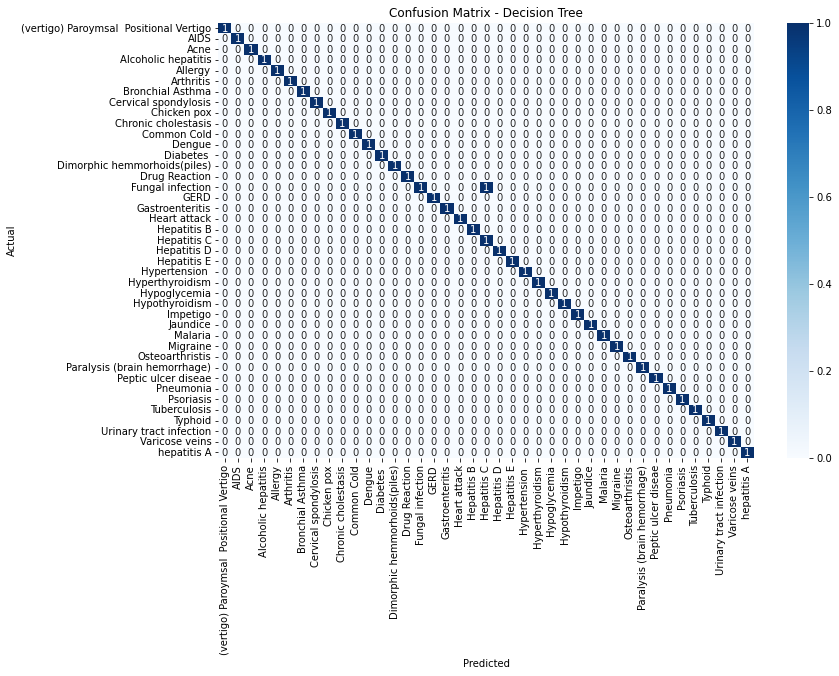


--- Training Random Forest ---
Accuracy: 0.9762
Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common C

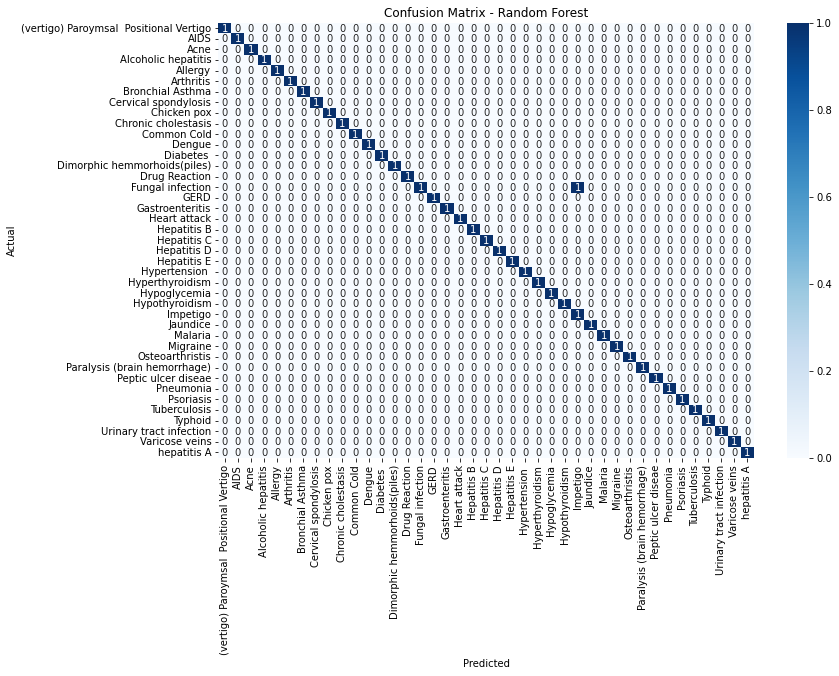


--- Training SVM ---
Accuracy: 1.0000
Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       

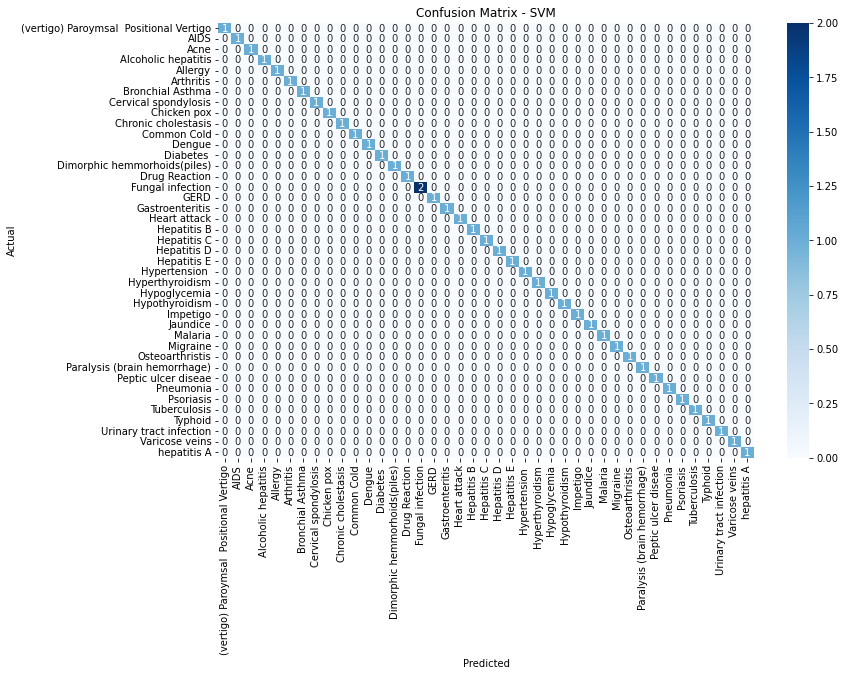

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Step 5.1: Load datasets with correct paths
train_data = pd.read_csv("../data/Training_data.csv")
test_data = pd.read_csv("../data/Testing_data.csv")

# Step 5.2: Split into features and target
target_column = "prognosis"
X_train = train_data.drop(columns=[target_column])
y_train = train_data[target_column]
X_test = test_data.drop(columns=[target_column])
y_test = test_data[target_column]

# Step 5.3: Align columns in X_train and X_test
print("Columns in X_train:", X_train.columns.tolist())
print("Columns in X_test:", X_test.columns.tolist())

# Option 1: Drop 'Unnamed: 133' from X_train (recommended if it's unnecessary)
if "Unnamed: 133" in X_train.columns:
    X_train = X_train.drop(columns=["Unnamed: 133"])

# Option 2: Add 'Unnamed: 133' to X_test (if it's required)
if "Unnamed: 133" not in X_test.columns:
    X_test["Unnamed: 133"] = 0  # or np.nan

# Ensure column order matches
X_test = X_test[X_train.columns]

print("\nAfter alignment:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Step 5.4: Encode y_train and y_test together
all_classes = pd.concat([y_train, y_test])
label_encoder = LabelEncoder()
label_encoder.fit(all_classes)

y_train = label_encoder.transform(y_train)
y_test = label_encoder.transform(y_test)

print("\nEncoded classes:", label_encoder.classes_)

# Step 5.5: Initialize and train models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate accuracy and classification report
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
    results[name] = {
        "accuracy": accuracy,
        "report": report
    }

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

# Cell 6: Save the Best Model

In [25]:
# Save the Decision Tree model (or any other model you prefer)
best_model = models["Decision Tree"]
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)
joblib.dump(best_model, f"{model_dir}/disease_prediction_model.pkl")
print("\nModel saved as 'disease_prediction_model.pkl'")


Model saved as 'disease_prediction_model.pkl'
